In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_agora = pd.read_excel('Results/AGORA2_details.xlsx', index_col=0)
df_agora.head()

,PubSeedID,2 - complete comparative genomics; 1 - certain comparative genomics; 0 - no comparative genomics,Strain,Species,Genus,Family,Order,Class,Phylum,Kingdom,...,Motility,Sample Body Site,Sample Body Subsite,Genome Size * assembled,Gene Count * assembled,GC Count * assembled,GC * assembled,CDS Count * assembled,CDS % * assembled,Genome link
MicrobeID,,,,,,,,,,,,,,,,,,,,,
Abiotrophia_defectiva_ATCC_49176,Abiotrophia defectiva ATCC 49176 (592010.4),2,Abiotrophia defectiva ATCC 49176,Abiotrophia defectiva,Abiotrophia,Aerococcaceae,Lactobacillales,Bacilli,Firmicutes,Bacteria,...,Nonmotile,NaN,0.0,2041839.0,2009.0,959280.0,47.0,1950.0,97.06,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...
Acaricomes_phytoseiuli_DSM_14247,Acaricomes phytoseiuli DSM 14247 (1120917.3),1,Acaricomes phytoseiuli DSM 14247,Acaricomes phytoseiuli,Acaricomes,Micrococcaceae,Micrococcales,Actinomycetia,Actinobacteria,Bacteria,...,Nonmotile,0.0,0.0,2419519.0,2387.0,1506904.0,62.0,2326.0,97.44,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...
Acaryochloris_marina_MBIC11017,NaN,0,Acaryochloris marina MBIC11017,Acaryochloris marina,Acaryochloris,Acaryochloridaceae,Synechococcales,unclassified Cyanobacteria,Cyanobacteria,Bacteria,...,Nonmotile,0.0,0.0,8361599.0,8488.0,3926263.0,47.0,8409.0,99.07,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...
Acetanaerobacterium_elongatum_CGMCC_1_5012,NaN,0,Acetanaerobacterium elongatum,Acetanaerobacterium elongatum,Acetanaerobacterium,Oscillospiraceae,Eubacteriales,Clostridia,Firmicutes,Bacteria,...,Motile,0.0,0.0,2916215.0,2842.0,1429234.0,49.0,2773.0,97.57,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/900...
Acetatifactor_muris_GP69,NaN,0,Acetatifactor muris,Acetatifactor muris,Acetatifactor,Lachnospiraceae,Eubacteriales,Clostridia,Firmicutes,Bacteria,...,Nonmotile,0.0,0.0,6013646.0,6002.0,2868509.0,48.0,5901.0,98.32,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/900...


In [3]:
# taking only the top 20 abundant families
top_families = df_agora.Family.value_counts().nlargest(20).index
df_agora_top_family = df_agora[df_agora.Family.isin(top_families)]
print(top_families)

Index(['Enterobacteriaceae', 'Streptococcaceae', 'Staphylococcaceae',
       'Enterococcaceae', 'Lachnospiraceae', 'Lactobacillaceae', 'Bacillaceae',
       'Helicobacteraceae', 'Moraxellaceae', 'Bacteroidaceae',
       'Clostridiaceae', 'Campylobacteraceae', 'Bifidobacteriaceae',
       'Pseudomonadaceae', 'Propionibacteriaceae', 'Peptostreptococcaceae',
       'Oscillospiraceae', 'Prevotellaceae', 'Pasteurellaceae',
       'Erysipelotrichaceae'],
      dtype='object', name='Family')


In [4]:
# taking only the top 20 abundant classes
top_classes = df_agora.Class.value_counts().nlargest(20).index
df_agora_top_class = df_agora[df_agora.Class.isin(top_classes)]
print(top_classes)

Index(['Bacilli', 'Gammaproteobacteria', 'Clostridia', 'Actinomycetia',
       'Bacteroidia', 'Epsilonproteobacteria', 'Betaproteobacteria',
       'Coriobacteriia', 'Erysipelotrichia', 'Negativicutes',
       'Alphaproteobacteria', 'Fusobacteriia', 'Tissierellia', 'Mollicutes',
       'Spirochaetia', 'Flavobacteriia', 'Deltaproteobacteria', 'Synergistia',
       'Deinococci', 'Cytophagia'],
      dtype='object', name='Class')


In [5]:
# code to plot tsne and umap plots
def plot_tsne_umap(data_all,data_new,df_agora_top_family,df_agora_top_class):
    fig,ax=plt.subplots(2,3,figsize=(25,7),gridspec_kw={'width_ratios': [1, 1, 0.25]})
    def plot(data,ax,l,t1,t2):
        # including only the top 20 families
        data1 = data.loc[df_agora_top_family.index]
        X1 = data1.values
        # getting the family names of the samples in data1 in same order as in data1
        y1 = df_agora_top_family.loc[data1.index,'Family'].values
        # including only the top 20 classes
        data2 = data.loc[df_agora_top_class.index]
        X2 = data2.values
        # getting the class names of the samples in data2 in same order as in data2
        y2 = df_agora_top_class.loc[data2.index,'Class'].values

        tsne1 = TSNE(
            n_components=2,             
            perplexity=30        
        )
        X_tsne1 = tsne1.fit_transform(X1)

        tsne2 = TSNE(
            n_components=2,             
            perplexity=30        
        )
        X_tsne2 = tsne2.fit_transform(X2)
        
        palette1 = sns.color_palette("hsv", len(np.unique(y1)))
        palette2 = sns.color_palette("hsv", len(np.unique(y2)))
        if l:
            sns.scatterplot(x=X_tsne1[:,0], y=X_tsne1[:,1], hue=y1, palette=palette1, legend='full', alpha=0.7,ax=ax[0])
            sns.scatterplot(x=X_tsne2[:,0], y=X_tsne2[:,1], hue=y2, palette=palette2, legend='full', alpha=0.7,ax=ax[1])
            ax[0].legend(ncol=2,bbox_to_anchor=(1.05, 1.1), loc='upper left', borderaxespad=0,fontsize=12)
            ax[1].legend(ncol=2,bbox_to_anchor=(1.05, 1.1), loc='upper left', borderaxespad=0,fontsize=12)
        else:
            sns.scatterplot(x=X_tsne1[:,0], y=X_tsne1[:,1], hue=y1, palette=palette1, legend=False, alpha=0.7,ax=ax[0])
            sns.scatterplot(x=X_tsne2[:,0], y=X_tsne2[:,1], hue=y2, palette=palette2, legend=False, alpha=0.7,ax=ax[1])
        
        # settting the xticks and xticklabels from -100 to 100 with a step of 25
        ax[0].set_xticks(np.arange(-100, 101, 25))
        ax[0].set_yticks(np.arange(-100, 101, 25))
        ax[1].set_xticks(np.arange(-100, 101, 25))
        ax[1].set_yticks(np.arange(-100, 101, 25))
        # setting the x and y axis limits
        ax[0].set_xlim(-100, 100)
        ax[0].set_ylim(-100, 100)
        ax[1].set_xlim(-100, 100)
        ax[1].set_ylim(-100, 100)
        ax[1].set_xticklabels(np.arange(-100, 101, 25), fontsize=12)
        ax[0].set_xticklabels([])
        if l==0:
            ax[0].set_yticklabels(np.arange(-100, 101, 25), fontsize=12)
            ax[1].set_yticklabels(np.arange(-100, 101, 25), fontsize=12)
        else:
            # setting empty xticklabels
            ax[0].set_yticklabels([])
            ax[1].set_yticklabels([])
        
        ax[0].set_title(t1, fontsize=15)
        ax[1].set_title(t2, fontsize=15)
    # code for diff data
    t1 = 'tSNE plot with top 20 abundant families (All reactions)'
    t2 = 'tSNE plot with top 20 abundant classes (All reactions)'
    plot(data_all,[ax[0,0],ax[1,0]],0,t1,t2)
    t1 = 'tSNE plot with top 20 abundant families (New reactions)'
    t2 = 'tSNE plot with top 20 abundant classes (New reactions)'
    plot(data_new,[ax[0,1],ax[1,1]],1,t1,t2)
    # empyting the other one spine
    ax[0,2].axis('off')
    ax[1,2].axis('off')
    plt.savefig('tsne_agora_ss.png', bbox_inches='tight')
    plt.show()
    return fig, ax


In [6]:
data1= pd.read_csv('Results/tsne_mat_all_ss.csv',index_col=0)
# remiving the .mat string from the ROW column
data1.index = data1.index.str.replace('.mat','',regex=False)
data1.head()

,Alanine and aspartate metabolism,Aminobenzoate degradation,Aminophosphonate metabolism,Aminosugar metabolism,Arginine and proline metabolism,Ascorbate and aldarate metabolism,Atrazine degradation,Benzoate degradation,Beta-alanine metabolism,Bile acid metabolism,...,Valerate metabolism,"Valine, leucine, and isoleucine metabolism",Vitamin B12 metabolism,Vitamin B2 metabolism,Vitamin B6 metabolism,Vitamin C metabolism,Wood-Ljungdahl Pathway,Xenobiotics metabolism,Zeatin biosynthesis,tRNA Charging
Row,,,,,,,,,,,,,,,,,,,,,
Abiotrophia_defectiva_ATCC_49176,12,0,0,15,18,0,0,2,2,0,...,0,34,9,6,11,0,0,0,1,2
Acaricomes_phytoseiuli_DSM_14247,12,1,0,10,26,0,0,1,7,0,...,0,43,11,12,7,0,1,2,0,2
Acaryochloris_marina_MBIC11017,13,1,0,13,32,1,0,2,5,0,...,0,36,40,12,13,0,2,2,1,2
Acetanaerobacterium_elongatum_CGMCC_1_5012,11,0,0,6,25,1,0,2,5,0,...,0,25,10,4,14,0,1,1,0,2
Acetatifactor_muris_GP69,10,2,0,14,17,0,0,0,2,0,...,0,32,8,5,16,0,1,0,0,2


In [7]:
data2= pd.read_csv('Results/tsne_mat_new_ss.csv',index_col=0)
# removing the .mat string from the ROW column
data2.index = data2.index.str.replace('.mat','',regex=False)
data2.head()

,Alanine and aspartate metabolism,Aminobenzoate degradation,Aminophosphonate metabolism,Aminosugar metabolism,Arginine and proline metabolism,Ascorbate and aldarate metabolism,Atrazine degradation,Benzoate degradation,Beta-alanine metabolism,Bile acid metabolism,...,Valerate metabolism,"Valine, leucine, and isoleucine metabolism",Vitamin B12 metabolism,Vitamin B2 metabolism,Vitamin B6 metabolism,Vitamin C metabolism,Wood-Ljungdahl Pathway,Xenobiotics metabolism,Zeatin biosynthesis,tRNA Charging
Row,,,,,,,,,,,,,,,,,,,,,
Abiotrophia_defectiva_ATCC_49176,4,0,0,3,7,0,0,2,0,0,...,0,14,4,1,7,0,0,0,1,1
Acaricomes_phytoseiuli_DSM_14247,4,0,0,1,12,0,0,1,3,0,...,0,13,2,1,4,0,1,2,0,0
Acaryochloris_marina_MBIC11017,3,0,0,2,12,1,0,2,1,0,...,0,11,15,0,5,0,2,2,1,0
Acetanaerobacterium_elongatum_CGMCC_1_5012,4,0,0,0,10,1,0,2,2,0,...,0,5,4,1,8,0,1,1,0,1
Acetatifactor_muris_GP69,3,2,0,2,3,0,0,0,2,0,...,0,8,1,1,9,0,1,0,0,1


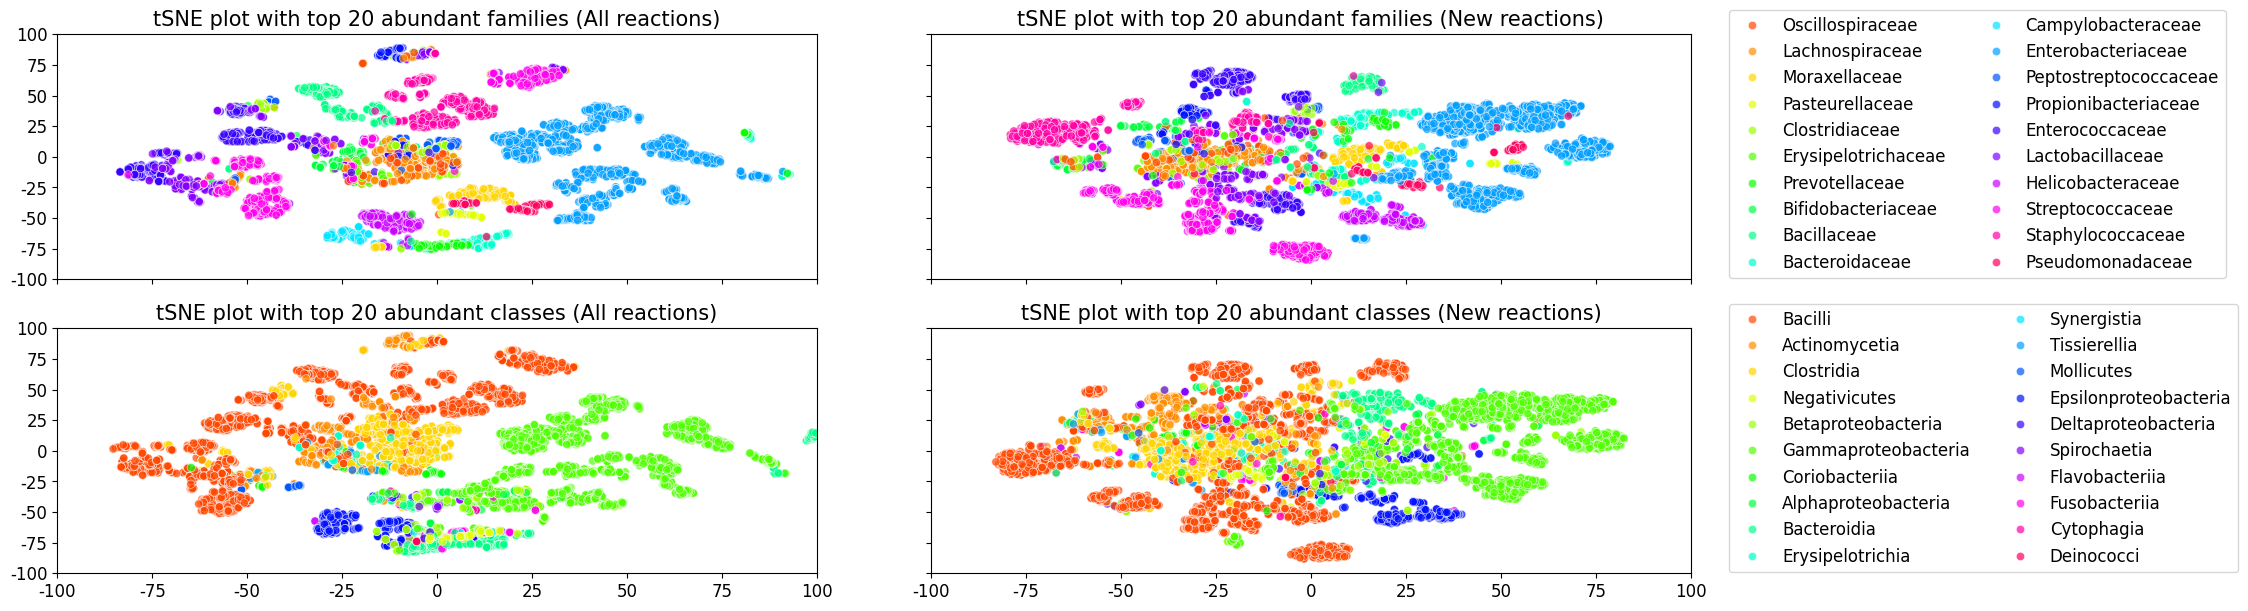

In [8]:
fig,ax=plot_tsne_umap(data1,data2,df_agora_top_family,df_agora_top_class)